In [ ]:
# This was trained on kaggle gpu

In [1]:
! pip install torch triton

In [2]:
! nvidia-smi

Tue Sep  1 15:56:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import triton
import triton.language as tl
import torch
from triton.runtime import driver

DEVICE = triton.runtime.driver.active.get_active_torch_device()


@triton.jit
def softmax_kernel(output_ptr, input_ptr, input_row_stride, output_row_stride, n_rows, n_cols, BLOCK_SIZE: tl.constexpr,
                   num_stages: tl.constexpr):

    # starting row of the program
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0)

    for row_idx in tl.range(row_start, n_rows, row_step, num_stages=num_stages):

        # The stride represents how much we need to increase the pointer to advance 1 row
        row_start_ptr = input_ptr + row_idx * input_row_stride

        # The block size is the next power of two greater than n_cols, so we can fit each
        # row in a single block
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets

        # Load the row into SRAM, using a mask since BLOCK_SIZE may be > than n_cols
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask=mask, other=-float('inf'))

        # Subtract maximum for numerical stability
        row_minus_max = row - tl.max(row, axis=0)


        numerator = tl.exp(row_minus_max)
        denominator = tl.sum(numerator, axis=0)
        softmax_output = numerator / denominator

        # Write back output to DRAM
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask=mask)


In [6]:

# This is NOT the kernel. It's the launcher: it figures out how many copies of
# the kernel to run so the GPU is exactly full, launches them once, and lets
# each copy loop over many rows.

# Softmax is row-wise (each row normalizes independently), so the natural
# mapping is: one program instance == one row at a time.



#Hardware limits, queried once at import time
properties = driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM     = properties["multiprocessor_count"]  # streaming multiprocessors on the GPU
NUM_REGS   = properties["max_num_regs"]          # register file size per SM
SIZE_SMEM  = properties["max_shared_mem"]        # shared memory per SM
WARP_SIZE  = properties["warpSize"]              # 32 on NVIDIA, 64 on AMD
target     = triton.runtime.driver.active.get_current_target()


kernels = {}  # cache: BLOCK_SIZE -> (compiled_kernel, num_programs)
              # without this we'd recompile on every single call


def softmax(x):
    n_rows, n_columns = x.size()

    # Each program loads an ENTIRE row into registers at once, so the tile must
    # cover the row. Triton wants power-of-2 tiles; a 1000-col row becomes a
    # 1024 block and the extra 24 lanes get masked off inside the kernel.
    BLOCK_SIZE = triton.next_power_of_2(n_columns)

    # 8 warps * 32 threads = 256 threads cooperating on one row.
    # More threads -> faster reductions (the row max and the row sum),
    # but fewer registers available to each thread.
    num_warps = 8

    # Software pipelining depth: while computing on row i, prefetch row i+1.
    # Deeper pipeline hides more memory latency but needs more shared memory
    # to hold the in-flight buffers, hence the SMEM check.
    num_stages = 4 if SIZE_SMEM > 200000 else 2

    output = torch.empty_like(x)  # empty_like, not zeros_like:
                                  # every element is overwritten anyway, so
                                  # zeroing first is a wasted pass over memory



    # OCCUPANCY CALCULATION (done once per BLOCK_SIZE, then cached)

    kernel, num_programs = kernels.get(BLOCK_SIZE, (None, 0))

    if kernel is None:
        # warmup() COMPILES the kernel without running it. We do this purely to
        # ask the compiler: "how much hardware does one instance of you use?"
        # You can't know n_regs / smem ahead of time

        kernel = softmax_kernel.warmup(
            output, x, x.stride(0), output.stride(0), n_rows, n_columns,
            BLOCK_SIZE=BLOCK_SIZE, num_stages=num_stages, num_warps=num_warps,
            grid=(1,),
        )
        kernel._init_handles()
        n_regs    = kernel.n_regs           # registers used PER THREAD
        size_smem = kernel.metadata.shared  # shared memory PER PROGRAM

        # How many programs fit on ONE SM (SM = Streaming Multiprocessor.), limited by registers?
        #   n_regs * WARP_SIZE * num_warps = total registers one program needs
        #   divide the SM's register file by that

        occupancy = NUM_REGS // (n_regs * WARP_SIZE * num_warps)

        # Shared memory is the other limiter. Take whichever bites first.
        occupancy = min(occupancy, SIZE_SMEM // size_smem)

        # Guard: if the kernel is register-hungry and BLOCK_SIZE is large, the
        # integer division can floor to 0 -> num_programs = 0 -> kernel
        # silently does nothing. Never let that happen.
        occupancy = max(occupancy, 1)

        # Scale from one SM to the whole GPU.
        num_programs = NUM_SM * occupancy

        kernels[BLOCK_SIZE] = (kernel, num_programs)

    # Never launch more programs than there are rows to process.
    num_programs = min(num_programs, n_rows)

    kernel[(num_programs, 1, 1)](
        output, x, x.stride(0), output.stride(0), n_rows, n_columns,
        BLOCK_SIZE, num_stages,
    )

    return output

In [9]:
torch.manual_seed(0)
x = torch.randn(1823, 781, device=DEVICE)
y_triton = softmax(x)
y_torch = torch.softmax(x, axis=1)
assert torch.allclose(y_triton, y_torch), (y_triton, y_torch)
print(y_triton)
print(y_torch)


tensor([[3.2747e-04, 5.3954e-04, 5.8687e-05,  ..., 5.5490e-04, 2.0330e-04,
         9.4091e-04],
        [8.6914e-04, 1.1075e-03, 1.0202e-04,  ..., 1.1470e-04, 5.5436e-04,
         8.6046e-04],
        [1.4101e-03, 1.0511e-03, 1.7031e-03,  ..., 1.2272e-03, 7.9059e-04,
         3.2380e-04],
        ...,
        [1.0722e-04, 3.6355e-04, 4.1703e-04,  ..., 3.5171e-04, 3.4261e-03,
         1.1834e-03],
        [6.7911e-04, 8.1645e-04, 6.9066e-04,  ..., 1.4361e-04, 9.6084e-04,
         2.5547e-03],
        [5.7850e-04, 9.4147e-04, 1.1231e-04,  ..., 3.4419e-03, 3.8817e-03,
         1.3192e-03]], device='cuda:0')
tensor([[3.2747e-04, 5.3954e-04, 5.8687e-05,  ..., 5.5490e-04, 2.0330e-04,
         9.4091e-04],
        [8.6914e-04, 1.1075e-03, 1.0202e-04,  ..., 1.1470e-04, 5.5436e-04,
         8.6046e-04],
        [1.4101e-03, 1.0511e-03, 1.7031e-03,  ..., 1.2272e-03, 7.9059e-04,
         3.2380e-04],
        ...,
        [1.0722e-04, 3.6355e-04, 4.1703e-04,  ..., 3.5171e-04, 3.4261e-03,
        

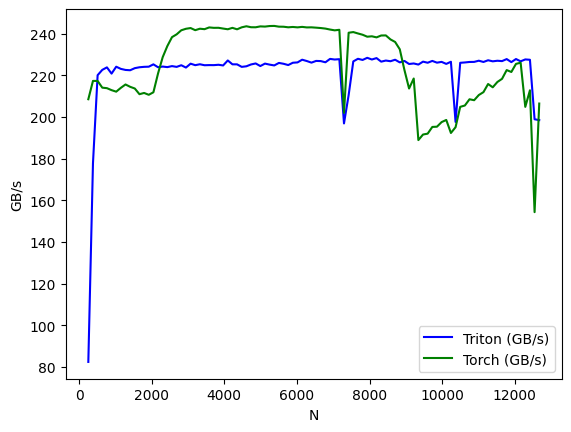

softmax-performance:
          N  Triton (GB/s)  Torch (GB/s)
0     256.0      82.463480    208.539342
1     384.0     177.778808    217.332802
2     512.0     220.079018    217.314223
3     640.0     222.629490    214.092097
4     768.0     223.831104    213.850371
5     896.0     220.843413    212.898484
6    1024.0     224.147339    212.171365
7    1152.0     223.103810    214.010373
8    1280.0     222.594901    215.622078
9    1408.0     222.453151    214.500069
10   1536.0     223.453008    213.681039
11   1664.0     223.879315    210.963701
12   1792.0     224.086361    211.551980
13   1920.0     224.157991    210.665821
14   2048.0     225.283251    211.871867
15   2176.0     223.893467    220.921178
16   2304.0     224.219326    228.732597
17   2432.0     223.957620    234.069620
18   2560.0     224.434218    238.339320
19   2688.0     224.065815    239.682341
20   2816.0     224.852090    241.636028
21   2944.0     223.736383    242.352436
22   3072.0     225.603249    242.70

In [10]:
#This is boilerplate code and not written by me 

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['triton', 'torch'],  # possible values for `line_arg``
        line_names=["Triton", "Torch"],  # label name for the lines
        styles=[('blue', '-'), ('green', '-')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)
    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda: softmax(x))
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)


benchmark.run(show_plots=True, print_data=True)